# Recipe Ranking Model Comparison

## I. Imports and Global Settings

Cell này nạp toàn bộ thư viện dùng cho pipeline học xếp hạng recipe và thiết lập các hằng số chung.

Các cấu hình chính:
- `RANDOM_STATE` để tái lập kết quả.
- `STOPWORDS` cho chuẩn hóa query tiếng Việt.
- `FEATURE_COLUMNS` là danh sách feature đầu vào model.
- `FEATURE_LABELS` là mô tả dễ đọc cho từng feature.

In [34]:
from __future__ import annotations

import json
import math
import re
import time
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Any, Callable

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from xgboost import XGBRanker

RANDOM_STATE = 42

STOPWORDS = {
    "toi", "muon", "hay", "cho", "biet", "tim", "kiem", "giup", "goi", "y",
    "mot", "mon", "an", "cong", "thuc", "lam", "nau", "chi", "huong", "dan",
    "co", "nao", "khong", "thoi", "gian", "moi", "ngay", "hom", "nay",
    "nhung", "cac", "la", "voi", "cho", "nguoi", "phan",
    "quan", "huyen", "tp", "thanh", "pho",
}

FEATURE_COLUMNS = [
    "ingredient_match_ratio",
    "serving_fit",
    "difficulty_fit",
    "prep_time_fit",
    "cook_time_fit",
    "total_time_fit",
    "prep_time_score",
    "cook_time_score",
    "category_match",
    "dish_name_match",
    "rating_score",
    "view_score",
    "text_match",
]

FEATURE_LABELS = {
    "ingredient_match_ratio": "Ingredient overlap between query and recipe",
    "serving_fit": "How well servings match requested people",
    "difficulty_fit": "Difficulty suitability for the user request",
    "prep_time_fit": "Preparation time suitability for requested time limit",
    "cook_time_fit": "Cooking time suitability for requested time limit",
    "total_time_fit": "Total prep + cook time suitability",
    "prep_time_score": "Global preference score for shorter prep time",
    "cook_time_score": "Global preference score for shorter cook time",
    "category_match": "Category intent overlap between query and recipe",
    "dish_name_match": "Dish name intent overlap between query and recipe",
    "rating_score": "Recipe quality score from popularity",
    "view_score": "Popularity signal from views",
    "text_match": "Text relevance between query and recipe profile",
}


## II. Feature Engineering

### II.1. Load and Merge the Data

Mục tiêu của cell này:
- Dùng dữ liệu recipe từ `dataset/recipes_processed.json` làm nguồn metadata chính.
- Dùng bảng nhãn truy vấn từ `dataset/recipes_dataset_ver1.csv`.
- Chuẩn hóa text (`dish_name`) để join nhãn với metadata recipe một cách ổn định.

Sau bước này, mỗi dòng biểu diễn cặp `(query, recipe)` kèm nhãn `label` và thông tin món ăn (nguyên liệu, thời gian, độ khó, độ phổ biến, URL).

In [35]:
def normalize_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("Đ", "D").replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

QUERY_PHRASE_REPLACEMENTS = {
    "toida": "toi da",
    "khongqua": "khong qua",
    "khauphan": "khau phan",
    "baonhieu": "bao nhieu",
}

QUERY_TOKEN_REPLACEMENTS = {
    "ng": "nguoi",
    "nguo": "nguoi",
    "nguoii": "nguoi",
    "ph": "phut",
    "p": "phut",
    "phu": "phut",
    "phutt": "phut",
    "gioo": "gio",
    "tiengg": "tieng",
    "nhanhh": "nhanh",
    "dee": "de",
    "khoo": "kho",
}

def normalize_query_text(query: Any) -> str:
    q = normalize_text(query)
    if not q:
        return ""

    q = re.sub(r"(\d)([a-z])", r"\1 \2", q)
    q = re.sub(r"([a-z])(\d)", r"\1 \2", q)

    for old, new in QUERY_PHRASE_REPLACEMENTS.items():
        q = re.sub(rf"\b{re.escape(old)}\b", new, q)

    normalized_tokens: list[str] = []
    for token in q.split():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)
        token = QUERY_TOKEN_REPLACEMENTS.get(token, token)
        for piece in token.split():
            if piece in {"h", "gio", "tieng"}:
                normalized_tokens.append("gio")
            elif piece in {"p", "ph", "phut"}:
                normalized_tokens.append("phut")
            elif piece in {"ng", "nguoi"}:
                normalized_tokens.append("nguoi")
            else:
                normalized_tokens.append(piece)

    deduped_tokens: list[str] = []
    for token in normalized_tokens:
        if not deduped_tokens or deduped_tokens[-1] != token:
            deduped_tokens.append(token)

    return " ".join(deduped_tokens).strip()

def normalize_recipe_id(value: Any) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    try:
        return str(int(float(text)))
    except Exception:
        return text

def tokenize(text: Any) -> list[str]:
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]

def tokenize_query(text: Any) -> list[str]:
    return [tok for tok in normalize_query_text(text).split() if tok and tok not in STOPWORDS]

def safe_float(value: Any, default: float = 0.0) -> float:
    try:
        if value is None or (isinstance(value, float) and pd.isna(value)):
            return default
        return float(value)
    except Exception:
        return default

def parse_ingredients(value: Any) -> list[dict[str, Any]]:
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

def extract_ingredient_names(value: Any) -> list[str]:
    names: list[str] = []
    for item in parse_ingredients(value):
        if isinstance(item, dict):
            name = normalize_text(item.get("name", ""))
            if name:
                names.append(name)
    return names

def normalize_category(value: Any) -> str:
    if isinstance(value, list):
        return " | ".join(str(item).strip() for item in value if str(item).strip())
    return str(value).strip() if value is not None else ""

def normalize_instructions(value: Any) -> str:
    if isinstance(value, list):
        parts: list[str] = []
        for step in value:
            if isinstance(step, dict):
                title = str(step.get("step_title", "")).strip()
                content = str(step.get("content", "")).strip()
                text = " ".join(part for part in [title, content] if part)
                if text:
                    parts.append(text)
            else:
                raw = str(step).strip()
                if raw:
                    parts.append(raw)
        return " ".join(parts)
    return str(value).strip() if value is not None else ""

def parse_servings_bin(text: Any) -> tuple[float, float]:
    s = normalize_text(text)
    if not s or s == "uncertain":
        return np.nan, np.nan

    range_match = re.search(r"(\d+)\s*-\s*(\d+)\s*nguoi", s)
    if range_match:
        low = float(range_match.group(1))
        high = float(range_match.group(2))
        return low, high

    single_match = re.search(r"(\d+)\s*nguoi", s)
    if single_match:
        value = float(single_match.group(1))
        return value, value

    return np.nan, np.nan

def parse_duration_to_minutes(text: Any) -> float:
    s = normalize_query_text(text)
    if not s:
        return np.nan

    if re.search(r"\bnua\s*(gio|tieng)\b", s):
        return 30.0

    hour_min_match = re.search(r"(\d+(?:\.\d+)?)\s*gio\s*(\d{1,2})?\s*(?:phut)?", s)
    if hour_min_match:
        hour = float(hour_min_match.group(1))
        minute = float(hour_min_match.group(2)) if hour_min_match.group(2) else 0.0
        return hour * 60.0 + minute

    minute_match = re.search(r"(\d+(?:\.\d+)?)\s*phut", s)
    if minute_match:
        return float(minute_match.group(1))

    return np.nan

def extract_requested_people(query: str) -> float:
    query_norm = normalize_query_text(query)

    range_patterns = [
        r"(\d{1,2})\s*-\s*(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)?",
        r"(\d{1,2})\s*(?:den|toi)\s*(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)?",
    ]
    for pattern in range_patterns:
        match = re.search(pattern, query_norm)
        if match:
            low = float(match.group(1))
            high = float(match.group(2))
            return (low + high) / 2.0

    single_patterns = [
        r"(?:cho|an|khau\s*phan|phan\s*an|suat)\s*(\d{1,2})\b",
        r"(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)\b",
    ]
    for pattern in single_patterns:
        match = re.search(pattern, query_norm)
        if match:
            return float(match.group(1))

    return np.nan

def extract_requested_max_minutes(query: str) -> float:
    query_norm = normalize_query_text(query)

    constrained_patterns = [
        r"(?:duoi|toi\s*da|khong\s*qua|it\s*hon|trong)\s*([a-z0-9\s]+)",
        r"(?:<=|<)\s*([a-z0-9\s]+)",
    ]
    for pattern in constrained_patterns:
        match = re.search(pattern, query_norm)
        if not match:
            continue
        tail_text = match.group(1).strip()
        minutes = parse_duration_to_minutes(tail_text)
        if not pd.isna(minutes):
            return float(minutes)
        number_only_match = re.search(r"\b(\d{1,3})\b", tail_text)
        if number_only_match:
            return float(number_only_match.group(1))

    direct_minutes = parse_duration_to_minutes(query_norm)
    if not pd.isna(direct_minutes):
        return float(direct_minutes)

    return np.nan

def popularity_to_rating(popularity: Any) -> float:
    popularity_norm = normalize_text(popularity)
    mapping = {
        "rat thap": 1.0,
        "thap": 2.0,
        "trung binh": 3.0,
        "cao": 4.0,
        "rat cao": 5.0,
        "thinh hanh": 4.5,
    }
    return mapping.get(popularity_norm, 2.5)

def build_recipe_frame(recipes_path: str | Path) -> pd.DataFrame:
    with Path(recipes_path).open("r", encoding="utf-8") as file:
        records = json.load(file)

    recipes_df = pd.DataFrame(records)
    recipes_df["recipe_id"] = [str(i + 1) for i in range(len(recipes_df))]

    if "dish_name" not in recipes_df.columns:
        recipes_df["dish_name"] = ""
    if "category" not in recipes_df.columns:
        recipes_df["category"] = ""
    if "instructions" not in recipes_df.columns:
        recipes_df["instructions"] = ""
    if "ingredients" not in recipes_df.columns:
        recipes_df["ingredients"] = [[] for _ in range(len(recipes_df))]
    if "servings_bin" not in recipes_df.columns:
        recipes_df["servings_bin"] = ""
    if "popularity" not in recipes_df.columns:
        recipes_df["popularity"] = ""
    if "views" not in recipes_df.columns:
        recipes_df["views"] = 0.0
    if "difficulty" not in recipes_df.columns:
        recipes_df["difficulty"] = 0.0
    if "prep_time_min" not in recipes_df.columns:
        recipes_df["prep_time_min"] = 0.0
    if "cook_time_min" not in recipes_df.columns:
        recipes_df["cook_time_min"] = 0.0
    if "url" not in recipes_df.columns:
        recipes_df["url"] = ""

    recipes_df["dish_name"] = recipes_df["dish_name"].fillna("").astype(str)
    recipes_df["category"] = recipes_df["category"].apply(normalize_category)
    recipes_df["instructions"] = recipes_df["instructions"].apply(normalize_instructions)
    recipes_df["ingredients_names"] = recipes_df["ingredients"].apply(extract_ingredient_names)
    recipes_df["views"] = pd.to_numeric(recipes_df["views"], errors="coerce").fillna(0.0)
    recipes_df["difficulty"] = pd.to_numeric(recipes_df["difficulty"], errors="coerce").fillna(0.0)
    recipes_df["prep_time_min"] = pd.to_numeric(recipes_df["prep_time_min"], errors="coerce").fillna(0.0)
    recipes_df["cook_time_min"] = pd.to_numeric(recipes_df["cook_time_min"], errors="coerce").fillna(0.0)
    recipes_df["url"] = recipes_df["url"].fillna("").astype(str)
    recipes_df["dish_name_norm"] = recipes_df["dish_name"].map(normalize_text)

    return recipes_df

def load_merged_recipe_ranking(
    labels_path: str | Path = Path("..") / "dataset" / "recipes_dataset_ver1.csv",
    recipes_path: str | Path = Path("..") / "dataset" / "recipes_processed.json",
) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path).copy()
    labels_df["dish_name"] = labels_df["dish_name"].fillna("").astype(str)
    labels_df["dish_name_norm"] = labels_df["dish_name"].map(normalize_text)
    labels_df["label"] = pd.to_numeric(labels_df.get("label", 0.0), errors="coerce").fillna(0.0)

    recipes_df = build_recipe_frame(recipes_path)
    query_index = set(labels_df["recipe_id"])
    
    filtered_recipe = recipes_df[recipes_df.index.isin(query_index)]
    
    filtered_recipe.loc[:,['recipe_id']] = filtered_recipe['recipe_id'].astype("int64")
    # The reciped_df have recipe_id start from 1, but the labels_df have recipe_id start from 0, so we need to minus 1 to match them
    filtered_recipe.loc[:,['recipe_id']] =filtered_recipe["recipe_id"].apply(lambda x: x - 1)
    
    merged_df = labels_df.merge(
        filtered_recipe,
        on="recipe_id",
        how="left",
        suffixes=("_label", ""),
    )

    if "dish_name_label" in merged_df.columns:
        merged_df["dish_name"] = merged_df["dish_name"].fillna(merged_df["dish_name_label"])

    return merged_df

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
LABELS_PATH = PROJECT_ROOT / "dataset" / "recipes_dataset.csv"
RECIPES_PATH = PROJECT_ROOT / "dataset" / "recipes_processed.json"
SPLIT_URLS_PATH = PROJECT_ROOT / "pre_processing" / "recipe_urls.csv"

raw_df = load_merged_recipe_ranking(LABELS_PATH, RECIPES_PATH)
print(f"Loaded merge shape: {raw_df.shape}")
print(f"Unique queries: {raw_df['query'].nunique()}")
display(raw_df[["query", "dish_name", "category", "url", "servings_bin", "difficulty", "prep_time_min", "cook_time_min", "views", "popularity", "label", "recipe_id"]].head(5))

Loaded merge shape: (3750, 21)
Unique queries: 250


,query,dish_name,category,url,servings_bin,difficulty,prep_time_min,cook_time_min,views,popularity,label,recipe_id
0,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá hồi làm bằng lò nướng,Món nướng | Ăn vặt,https://www.dienmayxanh.com/vao-bep/2-cach-lam-kho-ca-hoi-moi-la-thom-beo-don-gian-tai-nha-ai-10575,6-8 người,1,10,15,1676,Thấp,3,360
1,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Nướng cá bằng lò vi sóng,Món nướng,https://www.dienmayxanh.com/vao-bep/cach-nuong-ca-bang-lo-vi-song-thom-nuc-mui-ngon-khoi-che-01116,2-3 người,1,45,10,15086,Cao,2,752
2,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá nục,Món khô - mắm,https://www.dienmayxanh.com/vao-bep/cach-lam-kho-ca-nuc-phoi-nang-sieu-don-gian-va-hap-dan-10770,6-8 người,1,30,360,11649,Cao,0,10114
3,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Cá chỉ vàng nướng,Món nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-chi-vang-nuong-bia-bang-noi-chien-khong-dau-nhanh-22754,2-3 người,1,20,5,787,Thấp,1,111
4,Tôi muốn làm 1 món cá nướng cho 4 người ăn,cá hấp chiên,Món chiên,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-hap-chien-gion-voi-ca-nuc-mon-ngon-quen-lang-dam-23911,2-3 người,2,20,20,1,Rất thấp,0,3398


### II.2. Prepare the Base Feature Frame

Cell này chuẩn hóa dữ liệu đầu vào trước khi tạo feature:
- Ép kiểu và làm sạch các cột số, cột text.
- Tiền xử lý query người dùng: bỏ nhiễu, chuẩn hóa lỗi gõ thường gặp, chuẩn hóa đơn vị thời gian/khẩu phần.
- Chuẩn hóa query, tên món, category.
- Tạo `recipe_text` để phục vụ tính tương đồng văn bản.
- Tách thông tin khẩu phần và số người yêu cầu từ query.
- Trích ngưỡng thời gian nấu mong muốn (kể cả các case thiếu đơn vị như `duoi 30`).

In [36]:
def prepare_base_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_columns = ["prep_time_min", "cook_time_min", "difficulty", "views", "label"]
    for col in numeric_columns:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    text_columns = ["query", "dish_name", "category", "instructions", "servings_bin", "popularity", "url"]
    for col in text_columns:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    if "ingredients_names" not in df.columns:
        df["ingredients_names"] = [[] for _ in range(len(df))]
    df["ingredients_names"] = df["ingredients_names"].apply(
        lambda value: value if isinstance(value, list) else extract_ingredient_names(value)
    )

    if "recipe_id" not in df.columns:
        df["recipe_id"] = np.arange(1, len(df) + 1).astype(str)
    else:
        df["recipe_id"] = df["recipe_id"].map(normalize_recipe_id)

    # Query preprocessing: clean noisy text, fix common typos/abbreviations, and normalize units.
    df["query_raw_norm"] = df["query"].map(normalize_text)
    df["query_norm"] = df["query"].map(normalize_query_text)
    empty_query_mask = df["query_norm"].str.len() == 0
    df.loc[empty_query_mask, "query_norm"] = df.loc[empty_query_mask, "query_raw_norm"]

    df["dish_name_norm"] = df["dish_name"].map(normalize_text)
    df["category_norm"] = df["category"].map(normalize_text)
    df["recipe_text"] = (
        df["dish_name"].fillna("")
        + " | "
        + df["category"].fillna("")
        + " | "
        + df["ingredients_names"].apply(lambda items: " ".join(items))
    )
    df["recipe_text_norm"] = df["recipe_text"].map(normalize_text)

    servings_bounds = df["servings_bin"].apply(parse_servings_bin)
    df[["serving_low", "serving_high"]] = pd.DataFrame(servings_bounds.tolist(), index=df.index)
    df["serving_mid"] = (df["serving_low"] + df["serving_high"]) / 2.0
    df["requested_people"] = df["query_norm"].map(extract_requested_people)
    df["requested_max_minutes"] = df["query_norm"].map(extract_requested_max_minutes)

    return df

### II.3. Feature 1 - Text Match (`text_match`)

Feature này đo độ liên quan ngôn ngữ giữa query và hồ sơ món ăn.

Cách làm:
- Dùng `TF-IDF` trên `recipe_text_norm`.
- Biểu diễn query trong cùng không gian vector.
- Tính `cosine similarity` giữa query và recipe tương ứng.

Ý nghĩa:
- Gần `1.0`: query và mô tả món ăn khớp tốt.
- Gần `0.0`: ít trùng khớp từ khóa/ngữ cảnh.

In [37]:
def add_text_match_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    recipes = df[["recipe_id", "recipe_text_norm"]].drop_duplicates("recipe_id").reset_index(drop=True)
    recipe_index = {recipe_id: idx for idx, recipe_id in enumerate(recipes["recipe_id"])}

    min_df = 2 if len(recipes) >= 2 else 1
    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=min_df)
    recipe_word_matrix = word_vectorizer.fit_transform(recipes["recipe_text_norm"])
    query_word_matrix = word_vectorizer.transform(df["query_norm"])
    
    df["text_match"] = [
        float(cosine_similarity(query_word_matrix[idx], recipe_word_matrix[recipe_index[recipe_id]])[0, 0])
        for idx, recipe_id in enumerate(df["recipe_id"])
    ]
    
    return df

### II.4. Features - Ingredient, Serving, Category, Dish Name

Cell này tạo các tín hiệu intent quan trọng:
- `ingredient_match_ratio`: mức trùng token nguyên liệu giữa query và recipe.
- `serving_fit`: độ khớp giữa số người yêu cầu và `servings_bin`.
- `category_match`: mức khớp intent theo danh mục món ăn.
- `dish_name_match`: mức khớp intent theo tên món cụ thể.

Nhóm feature này giúp mô hình bắt đúng truy vấn ở cả mức nguyên liệu, ngữ cảnh món và ràng buộc khẩu phần.

In [38]:
def token_overlap_ratio(query_text: Any, target_text: Any) -> float:
    query_tokens = set(tokenize_query(query_text))
    target_tokens = set(tokenize(target_text))
    if not query_tokens or not target_tokens:
        return 0.0
    return float(len(query_tokens.intersection(target_tokens)) / len(query_tokens))

def compute_ingredient_match_ratio(row: pd.Series) -> float:
    query_source = row.get("query_norm", row.get("query", ""))
    query_tokens = set(tokenize_query(query_source))
    if not query_tokens:
        return 0.0

    ingredient_tokens: set[str] = set()
    for name in row.get("ingredients_names", []):
        ingredient_tokens.update(tokenize(name))

    if not ingredient_tokens:
        return 0.0

    overlap = len(query_tokens.intersection(ingredient_tokens))
    return float(overlap / max(len(query_tokens), 1))

def compute_serving_fit(row: pd.Series) -> float:
    requested = row.get("requested_people", np.nan)
    low = row.get("serving_low", np.nan)
    high = row.get("serving_high", np.nan)
    
    if pd.isna(requested) or pd.isna(low) or pd.isna(high):
        return 0.0

    if low <= requested <= high:
        return 1.0

    gap = min(abs(requested - low), abs(requested - high))
    return float(max(0.0, 1.0 - gap / max(requested, 1.0)))

def add_ingredient_and_serving_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    query_series = df["query_norm"] if "query_norm" in df.columns else df["query"]
    df["ingredient_match_ratio"] = df.apply(compute_ingredient_match_ratio, axis=1)
    df["serving_fit"] = df.apply(compute_serving_fit, axis=1)
    df["category_match"] = [
        token_overlap_ratio(query, category)
        for query, category in zip(query_series, df["category"])
    ]
    df["dish_name_match"] = [
        token_overlap_ratio(query, dish_name)
        for query, dish_name in zip(query_series, df["dish_name"])
    ]
    return df

### II.5. Features - Difficulty and Time (EDA-driven)

Cell này tạo các feature theo ràng buộc độ khó và thời gian:
- `difficulty_fit`: độ khớp mức khó theo intent query.
- `prep_time_fit`, `cook_time_fit`, `total_time_fit`: độ phù hợp theo ngưỡng thời gian (trực tiếp từ query hoặc suy luận quick-intent).
- `prep_time_score`, `cook_time_score`: điểm ưu tiên món có thời gian ngắn hơn theo rank.

Vì EDA cho thấy các biến thời gian lệch phải mạnh, điểm thời gian dùng rank-based score giúp ổn định hơn so với scale tuyến tính.

In [39]:
def extract_requested_difficulty(query: Any) -> float:
    query_norm = normalize_query_text(query)
    easy_terms = ["de nau", "don gian", "nhanh", "it buoc", "de lam"]
    hard_terms = ["kho", "phuc tap", "cau ky"]

    if any(term in query_norm for term in easy_terms):
        return 1.0
    if any(term in query_norm for term in hard_terms):
        return 3.0
    return np.nan

def infer_effective_max_minutes(query: Any, requested_max_minutes: float) -> float:
    if not pd.isna(requested_max_minutes) and requested_max_minutes > 0:
        return float(requested_max_minutes)

    query_norm = normalize_query_text(query)
    quick_terms = ["nhanh", "de nau", "it thoi gian", "duoi 30", "30 phut"]
    if any(term in query_norm for term in quick_terms):
        return 30.0
    return np.nan

def compute_difficulty_fit(row: pd.Series) -> float:
    requested = extract_requested_difficulty(row.get("query_norm", row.get("query", "")))
    recipe_difficulty = row.get("difficulty", np.nan)

    if pd.isna(requested) or pd.isna(recipe_difficulty):
        return 0.0

    return float(max(0.0, 1.0 - abs(recipe_difficulty - requested) / 3.0))

def compute_time_fit(time_value: float, requested_max: float) -> float:
    if pd.isna(requested_max) or requested_max <= 0 or pd.isna(time_value) or time_value <= 0:
        return 0.0
    if time_value <= requested_max:
        return 1.0
    overflow = time_value - requested_max
    return float(max(0.0, 1.0 - overflow / requested_max))

def inverse_rank_score(values: pd.Series) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce").fillna(0.0)
    if len(numeric_values) <= 1:
        return pd.Series(np.ones(len(numeric_values)), index=values.index)
    ranks = numeric_values.rank(method="average", pct=True)
    return (1.0 - ranks).clip(0.0, 1.0)

def add_difficulty_and_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    query_series = df["query_norm"] if "query_norm" in df.columns else df["query"]
    df["difficulty_fit"] = df.apply(compute_difficulty_fit, axis=1)

    df["effective_max_minutes"] = [
        infer_effective_max_minutes(query, requested_max)
        for query, requested_max in zip(query_series, df["requested_max_minutes"])
    ]

    total_time = pd.to_numeric(df["prep_time_min"], errors="coerce").fillna(0.0) + pd.to_numeric(df["cook_time_min"], errors="coerce").fillna(0.0)
    df["total_time_min"] = total_time

    df["prep_time_fit"] = [
        compute_time_fit(prep, max_time)
        for prep, max_time in zip(df["prep_time_min"], df["effective_max_minutes"])
    ]
    df["cook_time_fit"] = [
        compute_time_fit(cook, max_time)
        for cook, max_time in zip(df["cook_time_min"], df["effective_max_minutes"])
    ]
    df["total_time_fit"] = [
        compute_time_fit(total, max_time)
        for total, max_time in zip(df["total_time_min"], df["effective_max_minutes"])
    ]

    # EDA cho thay prep/cook time lech phai manh, nen dung rank score thay vi scale tuyen tinh.
    df["prep_time_score"] = inverse_rank_score(df["prep_time_min"])
    df["cook_time_score"] = inverse_rank_score(df["cook_time_min"])
    return df

### II.6. Feature 7 - Popularity-derived Rating (`rating_score`)

`rating_score` được ánh xạ từ trường `popularity` trong `recipes_processed.json` (rất thấp, thấp, trung bình, cao, rất cao, thịnh hành) sang thang điểm số rồi chuẩn hóa về `[0, 1]`.

In [40]:
def add_rating_score_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["rating_score"] = df["popularity"].map(popularity_to_rating) / 5.0
    return df

### II.7. Feature 8 - View Score (`view_score`)

`view_score` đo tín hiệu phổ biến của món dựa trên `views`.

Cách tính:
- Nén `views` bằng `log1p` để giảm lệch do outlier.
- Chuẩn hóa theo giá trị lớn nhất để đưa về `[0, 1]`.

Feature này bổ sung tín hiệu mức độ quan tâm thực tế của người dùng.

In [41]:
def add_view_score_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    view_signal = np.log1p(pd.to_numeric(df["views"], errors="coerce").fillna(0.0))
    max_signal = float(view_signal.max()) if len(view_signal) else 0.0
    df["view_score"] = view_signal / max_signal if max_signal > 0 else 0.0
    return df

## III. Preparing Data for Training

### Build the Final Feature Table

Hàm `build_recipe_features(...)` chạy toàn bộ pipeline feature engineering theo thứ tự thống nhất và đảm bảo tất cả cột trong `FEATURE_COLUMNS` đều là numeric.

Mỗi dòng sau bước này vẫn là cặp `(query, recipe)`, sẵn sàng đưa vào các mô hình học xếp hạng.

In [42]:
def build_recipe_features(df: pd.DataFrame) -> pd.DataFrame:
    df = prepare_base_frame(df)
    df = add_text_match_feature(df)
    df = add_ingredient_and_serving_features(df)
    df = add_difficulty_and_time_features(df)
    df = add_rating_score_feature(df)
    df = add_view_score_feature(df)

    for col in FEATURE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    return df

- Kiểm tra nhanh dữ liệu sau khi build feature

In [43]:
df = build_recipe_features(raw_df)
print(f"Shape of the feature dataframe: {df.shape}")
print(f"Number of features fed into the model: {len(FEATURE_COLUMNS)}")

feature_explanation_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "Explanation": [FEATURE_LABELS[col] for col in FEATURE_COLUMNS],
    }
)
display(feature_explanation_df)

preview_df = (
    df[[
        "query",
        "query_norm",
        "requested_people",
        "requested_max_minutes",
        "dish_name",
        "url",
        "label",
        *FEATURE_COLUMNS,
    ]]
    .head(10)
)
display(preview_df)

Shape of the feature dataframe: (3750, 46)
Number of features fed into the model: 13


,feature,Explanation
0,ingredient_match_ratio,Ingredient overlap between query and recipe
1,serving_fit,How well servings match requested people
2,difficulty_fit,Difficulty suitability for the user request
3,prep_time_fit,Preparation time suitability for requested time limit
4,cook_time_fit,Cooking time suitability for requested time limit
5,total_time_fit,Total prep + cook time suitability
6,prep_time_score,Global preference score for shorter prep time
7,cook_time_score,Global preference score for shorter cook time
8,category_match,Category intent overlap between query and recipe
9,dish_name_match,Dish name intent overlap between query and recipe


,query,query_norm,requested_people,requested_max_minutes,dish_name,url,label,ingredient_match_ratio,serving_fit,difficulty_fit,prep_time_fit,cook_time_fit,total_time_fit,prep_time_score,cook_time_score,category_match,dish_name_match,rating_score,view_score,text_match
0,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá hồi làm bằng lò nướng,https://www.dienmayxanh.com/vao-bep/2-cach-lam-kho-ca-hoi-moi-la-thom-beo-don-gian-tai-nha-ai-10575,3,0.25,0.50,0.0,0.0,0.0,0.0,0.720933,0.676133,0.25,0.50,0.4,0.542399,0.198215
1,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Nướng cá bằng lò vi sóng,https://www.dienmayxanh.com/vao-bep/cach-nuong-ca-bang-lo-vi-song-thom-nuc-mui-ngon-khoi-che-01116,2,0.25,0.75,0.0,0.0,0.0,0.0,0.091600,0.809200,0.25,0.50,0.8,0.702883,0.121505
2,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá nục,https://www.dienmayxanh.com/vao-bep/cach-lam-kho-ca-nuc-phoi-nang-sieu-don-gian-va-hap-dan-10770,0,0.25,0.50,0.0,0.0,0.0,0.0,0.194267,0.019733,0.00,0.25,0.8,0.683997,0.058709
3,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá chỉ vàng nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-chi-vang-nuong-bia-bang-noi-chien-khong-dau-nhanh-22754,1,0.25,0.75,0.0,0.0,0.0,0.0,0.352133,0.921333,0.25,0.50,0.4,0.487225,0.114298
4,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,cá hấp chiên,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-hap-chien-gion-voi-ca-nuc-mon-ngon-quen-lang-dam-23911,0,0.25,0.75,0.0,0.0,0.0,0.0,0.352133,0.521467,0.00,0.25,0.2,0.050636,0.086043
5,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Mực khô nướng,https://www.dienmayxanh.com/vao-bep/cach-nuong-muc-kho-bang-lo-vi-song-dai-ngon-sieu-nhanh-sieu-15117,1,0.00,0.75,0.0,0.0,0.0,0.0,0.905867,0.963467,0.25,0.25,1.0,0.735768,0.092075
6,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá bò nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-bo-kho-nuong-thom-lung-chuan-vi-cho-ban-nhau-13446,0,0.25,0.75,0.0,0.0,0.0,0.0,0.517333,0.676133,0.00,0.50,1.0,0.739856,0.089091
7,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá thu muối dùi,https://www.dienmayxanh.com/vao-bep/cac-lam-ca-thu-muoi-dui-don-gian-tai-nha-an-toan-ve-sinh-23474,0,0.25,0.50,0.0,0.0,0.0,0.0,0.103467,0.305867,0.00,0.25,0.2,0.332673,0.050075
8,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá nướng bơ,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-nuong-bo-ngon-la-de-lam-00493,1,0.25,0.75,0.0,0.0,0.0,0.0,0.194267,0.521467,0.25,0.50,0.4,0.552132,0.344374
9,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá trích nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-trich-nuong-thom-ngon-mem-ngot-de-lam-tai-nha-09596,4,0.25,1.00,0.0,0.0,0.0,0.0,0.517333,0.305867,0.25,0.50,0.8,0.675649,0.119255


### Shared Train/Test, Metrics, and Evaluation Helpers

Cell này định nghĩa phần dùng chung cho 3 model:
- Chia train/test theo URL từ `pre_processing/recipe_urls.csv` với tỉ lệ `21:4 (0.84:0.16)`.
- Bộ metric xếp hạng (`NDCG`, `MRR`, `HIT`).
- `GroupKFold` theo `query` để cross-validation.
- Hàm tune/evaluate thống nhất để so sánh model công bằng.

In [44]:
TRAIN_PERCENT = 0.85
CV_N_SPLITS = 10
CV_TOP_K = 5

def compute_group_metrics(eval_df: pd.DataFrame, score_col: str = "pred_score", top_ks: tuple[int, ...] = (5, 10)) -> dict[str, float]:
    ndcg_store = defaultdict(list)
    mrr_store: list[float] = []
    hit_store = {k: [] for k in top_ks}

    for _, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            score = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(score))

        relevant_positions = np.where(group["label"].to_numpy(dtype=float) >= 3)[0]
        mrr_store.append(float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 3).any()))

    metrics = {f"NDCG@{k}": float(np.mean(values)) for k, values in ndcg_store.items()}
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics

def compute_metrics_by_query(eval_df: pd.DataFrame, score_col: str = "pred_score", top_k: int = CV_TOP_K) -> pd.DataFrame:
    rows = []
    for query, group in eval_df.groupby("query"):
        ranked = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = ranked["label"].to_numpy(dtype=float)
        y_score = ranked[score_col].to_numpy(dtype=float)
        relevant_positions = np.where(y_true >= 3)[0]
        rows.append(
            {
                "query": query,
                "rows": len(ranked),
                f"NDCG@{top_k}": float(ndcg_score([y_true], [y_score], k=min(top_k, len(ranked)))),
                "MRR": float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0,
                f"HIT@{top_k}": float((ranked["label"].head(top_k) >= 3).any()),
            }
        )
    return pd.DataFrame(rows).sort_values([f"NDCG@{top_k}", "MRR"], ascending=False).reset_index(drop=True)

def build_grouped_train_test_split(
    df: pd.DataFrame,
    split_urls_path: str | Path,
    train_percent: float = TRAIN_PERCENT,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "url" not in df.columns:
        raise ValueError("DataFrame must contain a 'url' column for URL-based splitting.")

    rng = np.random.default_rng(random_state)
    
    unique_queries = pd.unique(df["query"])
    shuffled_queries = np.array(unique_queries, dtype=object)
    rng.shuffle(shuffled_queries)
    n_train_queries = max(1, int(np.floor(len(shuffled_queries) * train_percent)))
    n_train_queries = min(n_train_queries, len(shuffled_queries) - 1)
    train_queries = set(shuffled_queries[:n_train_queries])
    test_queries = set(shuffled_queries[n_train_queries:])
    train_df = df[df["query"].isin(train_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True)
    test_df = df[df["query"].isin(test_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True)

    return train_df, test_df

def empty_fit_kwargs(_: pd.DataFrame) -> dict[str, Any]:
    return {}

def group_fit_kwargs(train_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "model__group": train_df.groupby("query").size().tolist(),
    }

def evaluate_candidate(
    estimator,
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
) -> pd.DataFrame:
    fold_rows = []
    cv_source_df = train_df.reset_index(drop=True)
    X = cv_source_df[feature_columns]
    y = cv_source_df["label"].to_numpy(dtype=float)
    q_groups = cv_source_df["query"].to_numpy(dtype=object)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=q_groups), start=1):
        fold_train_df = (
            cv_source_df.iloc[train_idx]
            .sort_values(["query", "recipe_id"])
            .reset_index(drop=True)
        )
        fold_val_df = (
            cv_source_df.iloc[val_idx]
            .sort_values(["query", "recipe_id"])
            .reset_index(drop=True)
        )

        fold_estimator = clone(estimator)
        start_time = time.perf_counter()
        fold_estimator.fit(
            fold_train_df[feature_columns],
            fold_train_df["label"],
            **fit_kwargs_builder(fold_train_df),
        )
        fit_time = time.perf_counter() - start_time

        start_time = time.perf_counter()
        y_fold_pred = np.asarray(fold_estimator.predict(fold_val_df[feature_columns]), dtype=float).reshape(-1)
        predict_time = time.perf_counter() - start_time

        fold_eval_df = fold_val_df[["query", "label"]].copy()
        fold_eval_df["pred_score"] = y_fold_pred

        row = {
            "Fold": fold_idx,
            "Fit Time (s)": fit_time,
            "Predict Time (s)": predict_time,
        }
        row.update(compute_group_metrics(fold_eval_df, score_col="pred_score"))
        fold_rows.append(row)

    return pd.DataFrame(fold_rows)

def summarize_cv_results(model_name: str, candidate_id: int, params: dict[str, Any], fold_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "Model": model_name,
        "Candidate": candidate_id,
        "Params": params,
        "CV NDCG@5": fold_df["NDCG@5"].mean(),
        "CV NDCG@10": fold_df["NDCG@10"].mean(),
        "CV MRR": fold_df["MRR"].mean(),
        "CV HIT@5": fold_df["HIT@5"].mean(),
        "CV HIT@10": fold_df["HIT@10"].mean(),
        "CV NDCG@5 Std": fold_df["NDCG@5"].std(ddof=0),
        "CV NDCG@10 Std": fold_df["NDCG@10"].std(ddof=0),
        "CV MRR Std": fold_df["MRR"].std(ddof=0),
        "CV HIT@5 Std": fold_df["HIT@5"].std(ddof=0),
        "CV HIT@10 Std": fold_df["HIT@10"].std(ddof=0),
        "CV Mean Fit Time (s)": fold_df["Fit Time (s)"].mean(),
        "CV Mean Predict Time (s)": fold_df["Predict Time (s)"].mean(),
    }

def tune_model(
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    primary_metric: str = "NDCG@5",
) -> dict[str, Any]:
    candidate_rows = []
    best_candidate = None
    best_fold_df = None

    for candidate_id, params in enumerate(ParameterGrid(param_grid), start=1):
        configured_estimator = clone(estimator)
        configured_estimator.set_params(**params)

        fold_df = evaluate_candidate(
            configured_estimator,
            train_df,
            feature_columns,
            cv,
            fit_kwargs_builder,
        )
        summary_row = summarize_cv_results(model_name, candidate_id, params, fold_df)
        candidate_rows.append(summary_row)

        if (
            best_candidate is None
            or summary_row[f"CV {primary_metric}"] > best_candidate[f"CV {primary_metric}"]
            or (
                summary_row[f"CV {primary_metric}"] == best_candidate[f"CV {primary_metric}"]
                and summary_row["CV NDCG@10"] > best_candidate["CV NDCG@10"]
            )
        ):
            best_candidate = summary_row
            best_fold_df = fold_df.copy()

    candidates_df = pd.DataFrame(candidate_rows).sort_values(
        by=[f"CV {primary_metric}", "CV NDCG@10", "CV MRR"],
        ascending=False,
    ).reset_index(drop=True)

    return {
        "model_name": model_name,
        "candidates_df": candidates_df,
        "best_candidate": best_candidate,
        "best_fold_df": best_fold_df,
    }

def evaluate_on_test(
    model_name: str,
    estimator,
    best_params: dict[str, Any],
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: list[str],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None = None,
) -> tuple[dict[str, Any], dict[str, Any]]:
    final_estimator = clone(estimator)
    final_estimator.set_params(**best_params)

    x_train = train_df[feature_columns]
    y_train = train_df["label"]
    x_test = test_df[feature_columns]

    start_time = time.perf_counter()
    final_estimator.fit(x_train, y_train, **fit_kwargs_builder(train_df))
    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_test_pred = np.asarray(final_estimator.predict(x_test), dtype=float).reshape(-1)
    test_predict_time = time.perf_counter() - start_time

    test_eval_df = test_df[["query", "label", "recipe_id", "dish_name", *feature_columns]].copy()
    test_eval_df["pred_score"] = y_test_pred

    test_metrics = compute_group_metrics(test_eval_df, score_col="pred_score")
    test_metrics.update({
        "Model": model_name,
        "Train Time (s)": train_time,
        "Test Predict Time (s)": test_predict_time,
        "Best Params": best_params,
    })

    model_step = final_estimator.named_steps["model"]
    artifact = {
        "estimator": final_estimator,
        "eval_df": test_eval_df,
        "signal_values": getattr(model_step, signal_attr, None) if signal_attr else None,
    }
    return test_metrics, artifact

def build_model_summary(cv_result: dict[str, Any], test_metrics: dict[str, Any]) -> dict[str, Any]:
    return {
        "Model": cv_result["model_name"],
        "Best Params": cv_result["best_candidate"]["Params"],
        "CV NDCG@5": cv_result["best_candidate"]["CV NDCG@5"],
        "CV NDCG@10": cv_result["best_candidate"]["CV NDCG@10"],
        "CV MRR": cv_result["best_candidate"]["CV MRR"],
        "CV HIT@5": cv_result["best_candidate"]["CV HIT@5"],
        "CV HIT@10": cv_result["best_candidate"]["CV HIT@10"],
        "CV NDCG@5 Std": cv_result["best_candidate"]["CV NDCG@5 Std"],
        "CV NDCG@10 Std": cv_result["best_candidate"]["CV NDCG@10 Std"],
        "CV MRR Std": cv_result["best_candidate"]["CV MRR Std"],
        "CV HIT@5 Std": cv_result["best_candidate"]["CV HIT@5 Std"],
        "CV HIT@10 Std": cv_result["best_candidate"]["CV HIT@10 Std"],
        "CV Mean Fit Time (s)": cv_result["best_candidate"]["CV Mean Fit Time (s)"],
        "CV Mean Predict Time (s)": cv_result["best_candidate"]["CV Mean Predict Time (s)"],
        "Test NDCG@5": test_metrics["NDCG@5"],
        "Test NDCG@10": test_metrics["NDCG@10"],
        "Test MRR": test_metrics["MRR"],
        "Test HIT@5": test_metrics["HIT@5"],
        "Test HIT@10": test_metrics["HIT@10"],
        "Train Time (s)": test_metrics["Train Time (s)"],
        "Test Predict Time (s)": test_metrics["Test Predict Time (s)"],
    }

def build_signal_frame(signal_values: Any, feature_columns: list[str], signal_kind: str) -> pd.DataFrame:
    if signal_values is None:
        return pd.DataFrame(columns=["feature", "signal_raw", "signal_abs", "signal_norm", "signal_kind"])

    values = np.asarray(signal_values, dtype=float).reshape(-1)
    signal_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "signal_raw": values,
            "signal_abs": np.abs(values),
        }
    )
    total_signal = signal_df["signal_abs"].sum()
    signal_df["signal_norm"] = signal_df["signal_abs"] / total_signal if total_signal else 0.0
    signal_df["signal_kind"] = signal_kind
    return signal_df.sort_values("signal_abs", ascending=False).reset_index(drop=True)

def register_model_run(
    run_key: str,
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None,
    signal_kind: str,
) -> dict[str, Any]:
    cv_result = tune_model(
        model_name=model_name,
        estimator=estimator,
        param_grid=param_grid,
        train_df=train_df,
        feature_columns=FEATURE_COLUMNS,
        cv=cv_strategy,
        fit_kwargs_builder=fit_kwargs_builder,
        primary_metric="NDCG@5",
    )
    test_metrics, artifact = evaluate_on_test(
        model_name=model_name,
        estimator=estimator,
        best_params=cv_result["best_candidate"]["Params"],
        train_df=train_df,
        test_df=test_df,
        feature_columns=FEATURE_COLUMNS,
        fit_kwargs_builder=fit_kwargs_builder,
        signal_attr=signal_attr,
    )
    summary = build_model_summary(cv_result, test_metrics)
    signal_df = build_signal_frame(artifact["signal_values"], FEATURE_COLUMNS, signal_kind)
    signal_df["Model"] = model_name
    per_query_df = compute_metrics_by_query(artifact["eval_df"], top_k=CV_TOP_K)
    per_query_df["Model"] = model_name

    run = {
        "model_name": model_name,
        "cv_result": cv_result,
        "artifact": artifact,
        "summary": summary,
        "signal_df": signal_df,
        "per_query_df": per_query_df,
    }
    model_runs[run_key] = run
    display(pd.DataFrame(cv_result["best_candidate"]["Params"], index=["Value"]).T)
    display(pd.DataFrame([summary]))
    return run

train_df, test_df = build_grouped_train_test_split(
    df,
    split_urls_path=SPLIT_URLS_PATH,
    train_percent=TRAIN_PERCENT,
    random_state=RANDOM_STATE,
)
print(f"train/test lines: {len(train_df)} / {len(test_df)}")
print(f"train/test urls: {train_df['url'].nunique()} / {test_df['url'].nunique()}")
print(f"train/test queries: {train_df['query'].nunique()} / {test_df['query'].nunique()}")

n_splits = min(CV_N_SPLITS, train_df["query"].nunique())
if n_splits < 2:
    raise ValueError("Not enough unique queries for the specified number of cross-validation splits.")

cv_strategy = GroupKFold(n_splits=n_splits)
print(f"Using {n_splits}-fold GroupKFold for cross-validation.")

model_runs: dict[str, dict[str, Any]] = {}

train/test lines: 3180 / 570
train/test urls: 1116 / 400
train/test queries: 212 / 38
Using 10-fold GroupKFold for cross-validation.


## IV. Train and Compare Models

### IV.1. Model 1 - LightGBM Ranker

Cell này khởi tạo `LightGBMRanker`, định nghĩa grid tham số và chạy tuning/evaluation trên cùng pipeline.

Lưu ý:
- Dùng `fit_kwargs_builder=group_fit_kwargs` vì bài toán learning-to-rank cần kích thước group theo query.
- `signal_attr="feature_importances_"` để lấy độ quan trọng feature phục vụ phân tích.

In [45]:
lgbm_pipeline = Pipeline(
    [
        (
            "model",
            lgb.LGBMRanker(
                objective="rank_xendcg",
                learning_rate=0.05,
                # min_child_samples=20,
                min_child_samples=70,
                # subsample=0.9,
                # colsample_bytree=0.9,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        )
    ]
)

LGBM_PARAM_GRID = {
    "model__n_estimators": [50, 70, 100, 150],
    "model__max_depth": [4, 5, 6],
    "model__num_leaves": [5, 10, 15, 20, 30],
    "model__max_bin": [31, 63, 127],
    # "model__min_gain_to_split": [0.0, 0.1, 0.2, 0.3,1,2,4,5,10],
}

lightgbm_run = register_model_run(
    run_key="lightgbm",
    model_name="LightGBM Ranker",
    estimator=lgbm_pipeline,
    param_grid=LGBM_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
)

,Value
model__max_bin,31
model__max_depth,5
model__n_estimators,150
model__num_leaves,20


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,LightGBM Ranker,"{'model__max_bin': 31, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__num_leaves': 20}",0.79518,0.839227,0.743331,0.829437,0.862554,0.03906,0.033312,0.071462,0.083835,0.072601,0.061414,0.002884,0.829862,0.866676,0.78748,0.842105,0.842105,0.0625,0.003992


### IV.2. Model 2 - Ridge Ranker

Cell này huấn luyện `Ridge` như baseline tuyến tính và dò `alpha` bằng cùng quy trình CV.

Ưu điểm:
- Nhanh.
- Dễ diễn giải (hệ số tuyến tính).

Nhược điểm:
- Chỉ mô hình hóa quan hệ tuyến tính giữa feature và điểm relevance.

In [46]:
ridge_pipeline = Pipeline(
    [
        (
            "model",
            Ridge(random_state=RANDOM_STATE),
        )
    ]
)

RIDGE_PARAM_GRID = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

ridge_run = register_model_run(
    run_key="ridge",
    model_name="Ridge Ranker",
    estimator=ridge_pipeline,
    param_grid=RIDGE_PARAM_GRID,
    fit_kwargs_builder=empty_fit_kwargs,
    signal_attr="coef_",
    signal_kind="coefficient",
)

,Value
model__alpha,10.0


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,Ridge Ranker,{'model__alpha': 10.0},0.738448,0.801811,0.706516,0.815584,0.848485,0.042566,0.042949,0.08486,0.081678,0.073847,0.002143,0.001237,0.781063,0.839797,0.708897,0.815789,0.842105,0.001608,0.000836


### IV.3. Model 3 - XGBoost Ranker

Cell này khởi tạo `XGBRanker`, chạy grid search và đánh giá theo cùng protocol.

Lưu ý:
- Dùng objective pairwise cho bài toán ranking.
- Cần group theo query khi fit.
- Dùng `feature_importances_` để so sánh ảnh hưởng feature giữa các model.

In [47]:
xgb_pipeline = Pipeline(
    [
        (
            "model",
            XGBRanker(
                objective="rank:pairwise",
                eval_metric=["ndcg@5", "ndcg@10"],
                learning_rate=0.05,
                subsample=0.85,
                # subsample=1.0,
                colsample_bytree=1.0,
                reg_alpha=0.0,
                reg_lambda=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
                gamma = 0.1,
                
            ),
        )
    ]
)

XGB_PARAM_GRID = {
    "model__n_estimators": [30, 50, 70, 100, 150],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [1, 2, 3, 5],
}

xgboost_run = register_model_run(
    run_key="xgboost",
    model_name="XGBoost Ranker",
    estimator=xgb_pipeline,
    param_grid=XGB_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
)

,Value
model__max_depth,5
model__min_child_weight,1
model__n_estimators,70


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,XGBoost Ranker,"{'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 70}",0.79586,0.838241,0.750551,0.834416,0.862771,0.036154,0.026517,0.081991,0.072109,0.058787,0.091483,0.005009,0.813385,0.860411,0.765915,0.842105,0.842105,0.093223,0.004358


## V. Models analysis


Cell này tổng hợp kết quả của tất cả model và sắp xếp theo các chỉ số test chính:
- `Test NDCG@5`
- `Test NDCG@10`
- `Test MRR`

Bảng kết quả giúp so sánh trực tiếp chất lượng mô hình trên cùng pipeline đánh giá.

In [48]:
comparison_summary_df = (
    pd.DataFrame([run["summary"] for run in model_runs.values()])
    .sort_values(["Test NDCG@5", "Test NDCG@10", "Test MRR"], ascending=False)
    .reset_index(drop=True)
)
display(comparison_summary_df)

,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,LightGBM Ranker,"{'model__max_bin': 31, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__num_leaves': 20}",0.795180,0.839227,0.743331,0.829437,0.862554,0.039060,0.033312,0.071462,0.083835,0.072601,0.061414,0.002884,0.829862,0.866676,0.787480,0.842105,0.842105,0.062500,0.003992
1,XGBoost Ranker,"{'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 70}",0.795860,0.838241,0.750551,0.834416,0.862771,0.036154,0.026517,0.081991,0.072109,0.058787,0.091483,0.005009,0.813385,0.860411,0.765915,0.842105,0.842105,0.093223,0.004358
2,Ridge Ranker,{'model__alpha': 10.0},0.738448,0.801811,0.706516,0.815584,0.848485,0.042566,0.042949,0.084860,0.081678,0.073847,0.002143,0.001237,0.781063,0.839797,0.708897,0.815789,0.842105,0.001608,0.000836


## Accuracy vs Computational Cost

Phần này trực quan hóa trade-off giữa hiệu quả xếp hạng và chi phí tính toán:
- Biểu đồ trái: các metric test.
- Biểu đồ phải: thời gian train và predict.

Mục tiêu là chọn mô hình không chỉ tốt về điểm số mà còn phù hợp chi phí triển khai.

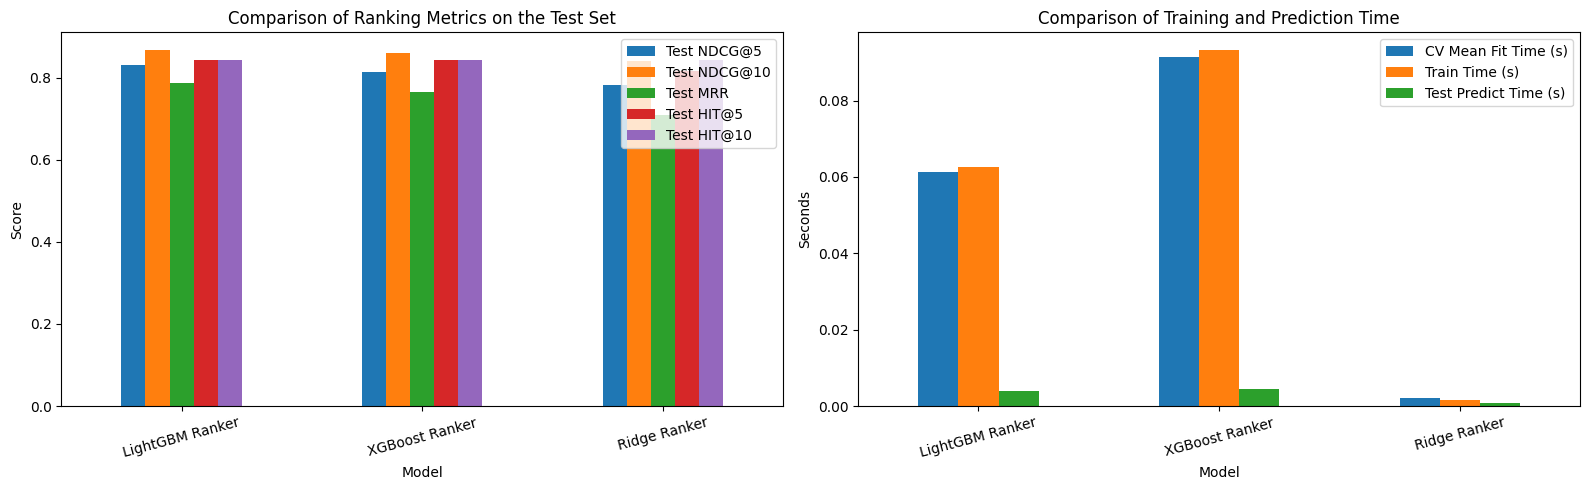

In [49]:
metric_cols = ["Test NDCG@5", "Test NDCG@10", "Test MRR", "Test HIT@5", "Test HIT@10"]
timing_cols = ["CV Mean Fit Time (s)", "Train Time (s)", "Test Predict Time (s)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
comparison_summary_df.set_index("Model")[metric_cols].plot(kind="bar", ax=axes[0])
axes[0].set_title("Comparison of Ranking Metrics on the Test Set")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=15)

comparison_summary_df.set_index("Model")[timing_cols].plot(kind="bar", ax=axes[1])
axes[1].set_title("Comparison of Training and Prediction Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


Kết quả thường cho thấy 3 mô hình có chất lượng xếp hạng khá sát nhau trên cùng bộ feature recipe. Mô hình tuyến tính (Ridge) thường có lợi thế về tốc độ, trong khi LightGBM/XGBoost có xu hướng linh hoạt hơn khi học tương tác phi tuyến.

Vì vậy, lựa chọn mô hình cuối cùng nên cân bằng giữa:
- chất lượng metric (NDCG/MRR/HIT),
- chi phí huấn luyện/suy luận,
- và mức độ dễ giải thích khi triển khai.

### Comparing Feature Signals Across Models

Trong notebook này, `signal` là tên chung cho mức ảnh hưởng của feature:
- Với LightGBM/XGBoost: `signal` là feature importance.
- Với Ridge: `signal` là độ lớn hệ số `coef_`.

Để so sánh công bằng, các giá trị được lấy trị tuyệt đối và chuẩn hóa thành `signal_norm`.
Vì vậy, biểu đồ nên được đọc theo ý nghĩa tương đối giữa các feature, không phải theo đơn vị gốc của từng model.

Model,LightGBM Ranker,Ridge Ranker,XGBoost Ranker
feature_label,,,
Recipe quality score from popularity,0.027994,0.028186,0.052500
Difficulty suitability for the user request,0.051859,0.002573,0.060252
Preparation time suitability for requested time limit,0.020652,0.018496,0.067728
Ingredient overlap between query and recipe,0.070216,0.009281,0.066286
Cooking time suitability for requested time limit,0.007802,0.022006,0.070757
Total prep + cook time suitability,0.048646,0.058018,0.080738
Global preference score for shorter cook time,0.089950,0.031766,0.061843
Global preference score for shorter prep time,0.095916,0.057770,0.063435
How well servings match requested people,0.100046,0.028065,0.109847


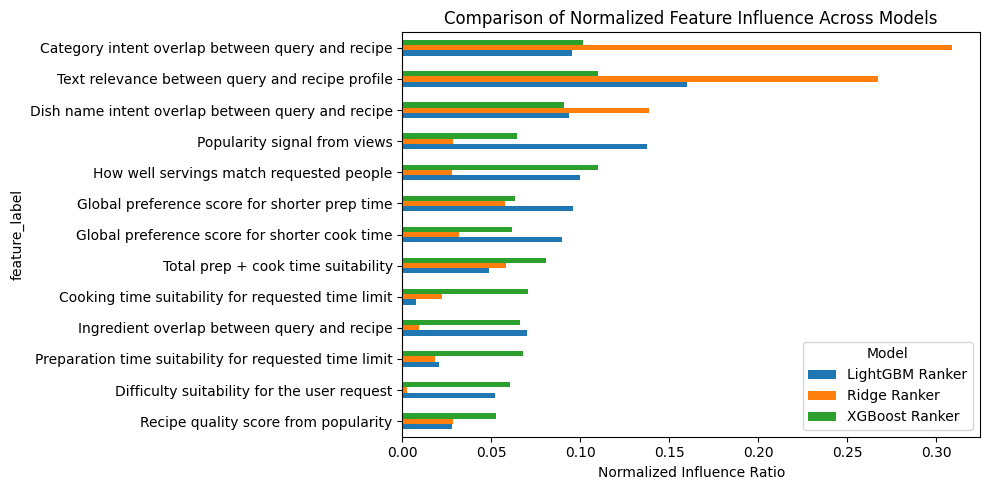

In [50]:
signal_compare_df = pd.concat([run["signal_df"] for run in model_runs.values()], ignore_index=True)
signal_compare_df["feature_label"] = signal_compare_df["feature"].map(FEATURE_LABELS)
signal_pivot_df = (
    signal_compare_df
    .pivot(index="feature_label", columns="Model", values="signal_norm")
    .fillna(0.0)
)
signal_pivot_df = signal_pivot_df.loc[signal_pivot_df.max(axis=1).sort_values(ascending=True).index]
display(signal_pivot_df)

plt.figure(figsize=(10, 5))
signal_pivot_df.plot(kind="barh", ax=plt.gca())
plt.title("Comparison of Normalized Feature Influence Across Models")
plt.xlabel("Normalized Influence Ratio")
plt.tight_layout()
plt.show()


Biểu đồ cho thấy mỗi mô hình dùng feature theo cách khác nhau dù cùng tập dữ liệu.

Các xu hướng thường gặp:
- `text_match` và `ingredient_match_ratio` thường là hai tín hiệu mạnh vì bám sát ý định truy vấn.
- `serving_fit` hữu ích khi query có số người cụ thể.
- `difficulty_fit`, `prep_time_fit`, `cook_time_fit` phát huy khi query có ràng buộc "dễ nấu" hoặc thời gian.
- `rating_score` và `view_score` đóng vai trò tín hiệu phổ biến/chất lượng để bổ trợ xếp hạng.

Từ đó có thể tiếp tục tối ưu bằng cách mở rộng parser query và thêm đặc trưng ngữ nghĩa sâu hơn.

---

## Conclusion

Notebook đã được đồng bộ theo dữ liệu recipe:
- Metadata recipe lấy từ `dataset/recipes_processed.json`.
- Chia train/test theo URL trong `pre_processing/recipe_urls.csv` với tỉ lệ `8:2`.
- Toàn bộ feature và mô tả markdown đã chuyển sang ngữ cảnh recommendation cho món ăn.

Từ baseline hiện tại, có thể cải thiện thêm bằng cách tăng chất lượng parser tiếng Việt và bổ sung feature semantic cho mức khớp query-recipe.